<div style="background: linear-gradient(135deg, #1e1b4b, #312e81); color:white; padding:25px; border-radius:10px;
            text-align:center; font-family:'Segoe UI', sans-serif;">

  <h1 style="margin-bottom:8px;"> WikiArt Image Classification</h1>
  <h3 style="margin-top:0; font-style:italic; font-weight:normal; color:#a5b4fc;">
    Transfer Learning with ResNet50
  </h3>

  <hr style="width:60%; border:1px solid #6366f1; margin:15px auto;">

  <p style="margin:5px 0; font-size:15px;">
    <b>Group Project</b> - Deep Learning (2025/2026)
  </p>
  <p style="margin:0; font-size:13px; color:#c7d2fe;">
    Master in Data Science and Advanced Analytics - Nova Information Management School
  </p>
</div>

<br>

<div style="background-color:#1e293b; color:#e0e7ff; padding:15px 20px; border-left:5px solid #6366f1;
            border-radius:6px; font-family:'Segoe UI', sans-serif; font-size:14px;">

  <b>Notebook Description</b><br>
  Transfer learning approach using a ResNet50 backbone pretrained on ImageNet,
  fine-tuned for artist classification on the WikiArt dataset.
  The model is evaluated using macro F1 score to account for class imbalance across the 23 artist categories.

</div>

<br>

**<h3>Table of Contents</h3>**
* [1. Environment Setup](#1-environment-setup)
* [2. Model Implementation](#2-model)
* [3. Model Evaluation](#3-model2)

<div id="1-environment-setup" style="background-color:#1e293b; padding:18px; border-radius:6px;">
  <h2 style="margin:0; color:#a5b4fc;">
    1. Setup
  </h2>
</div>

## 1.1 Libraries imports

In [18]:
import sys
import os

import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
import keras
from keras import layers
import yaml

from tensorflow.keras.applications import ResNet50
from tensorflow.keras.applications.resnet50 import preprocess_input

sys.path.append(os.path.abspath('../src'))

from utils import (
    evaluate_model,
    load_datasets,
    plot_learning_curves,
    save_history,
    set_seeds,
    predict_tta,
    evaluate_from_predictions,
)

# load config
with open('../config.yml', 'r') as f:
    config = yaml.safe_load(f)

## 1.2 Google Colab Setup

The ResNet50 experiments were run on Google Colab (T4, 16 GB VRAM) because our local GPUS could not fit the model at a usable batch size, especially during the fine-tuning phase, where unfreezing part of the backbone roughly doubles memory usage due to the additional gradients and activations that must be stored. Colab's T4 allowed training at 256×256 with batch size 16 and MixUp augmentation, which would have been infeasible locally. The notebook auto-detects the environment (IN_COLAB flag) and switches between local and Drive-mounted paths, so the same code runs in both setups without modification.

In [3]:
SEED = 42

try:
    from google.colab import drive
    IN_COLAB = True
except ImportError:
    IN_COLAB = False

if IN_COLAB:
    drive.mount('/content/drive')
    DRIVE_PROJECT = '/content/drive/MyDrive/Deep-learning-project'
    LOCAL_DATA = '/content/data'

    if not os.path.exists(LOCAL_DATA):
        print("Unzipping dataset from Drive...")
        !unzip -q "$DRIVE_PROJECT/data.zip" -d /content/
        print("Done.")
    else:
        print(f"{LOCAL_DATA} already exists, skipping unzip.")

    sys.path.append(f'{DRIVE_PROJECT}/src')
    CONFIG_PATH = f'{DRIVE_PROJECT}/config.yml'
else:
    sys.path.append(os.path.abspath('../src'))
    CONFIG_PATH = '../config.yml'

from utils import *

# Load config
import yaml
with open(CONFIG_PATH, 'r') as f:
    config = yaml.safe_load(f)

set_seeds(config['seed'])

# Paths: in Colab override to local copies, otherwise use config paths
if IN_COLAB:
    train_dir = f'{LOCAL_DATA}/train'
    val_dir   = f'{LOCAL_DATA}/val'
    test_dir  = f'{LOCAL_DATA}/test'
else:
    train_dir = config['paths']['train_dir']
    val_dir   = config['paths']['val_dir']
    test_dir  = config['paths']['test_dir']

# Checkpoint paths
if IN_COLAB:
    CHECKPOINT_DIR = f'{DRIVE_PROJECT}/models_results/resnet50'
    os.makedirs(CHECKPOINT_DIR, exist_ok=True)
    checkpoint_path = f'{CHECKPOINT_DIR}/resnet50_v3_best.keras'
    history_path = f'{CHECKPOINT_DIR}/resnet50_historyv3.json'
else:
    checkpoint_path = config['models']['resnet50']['checkpoint']
    history_path = config['models']['resnet50']['history']
    os.makedirs(os.path.dirname(checkpoint_path), exist_ok=True)

Mounted at /content/drive
Unzipping dataset from Drive...
Done.


<div id="2-model" style="background-color:#1e293b; padding:18px; border-radius:6px;">
  <h2 style="margin:0; color:#a5b4fc;">
    2. Model Implementation
  </h2>
</div>

## 2.1 Transfer Learning using ResNet50

In [ ]:
IMG_SIZE = (256, 256)
BATCH_SIZE = 16
NUM_CLASSES = 23

train_ds, val_ds, test_ds, class_names = load_datasets(
    train_dir, val_dir, test_dir,
    img_size=IMG_SIZE, batch_size=BATCH_SIZE,
)

# Data Augmentation: flip, rotate, zoom, contrast
data_augmentation = keras.Sequential([
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.10),
    layers.RandomZoom(0.15),
    layers.RandomContrast(0.15),
], name="data_augmentation")

# MixUp: mixes two random samples in the batch, both images and labels, via a random weight from a Beta distribution and then computes a weighted average. For labels, this creates soft labels that can help regularize the model and improve generalization.
def mixup_batch(images, labels, alpha=0.2):
    batch_size = tf.shape(images)[0]

    # Beta distribution gives us a random weight between 0 and 1, where alpha controls the strength of the mixup (smaller alpha = more similar to original samples, larger alpha = more mixed).
    # Implementation: sample two gamma distributions and compute the mixup weight as gamma1 / (gamma1 + gamma2) to get a value in (0, 1).
    gamma1 = tf.random.gamma([batch_size], alpha)
    gamma2 = tf.random.gamma([batch_size], alpha)
    lam = gamma1 / (gamma1 + gamma2)

    # Reshape for broadcasting: lam_img for images (batch_size, 1, 1, 1) and lam_lab for labels (batch_size, 1).
    lam_img = tf.reshape(lam, [batch_size, 1, 1, 1])
    lam_lab = tf.reshape(lam, [batch_size, 1])

    idx = tf.random.shuffle(tf.range(batch_size))
    mixed_images = lam_img * images + (1 - lam_img) * tf.gather(images, idx)
    mixed_labels = lam_lab * labels + (1 - lam_lab) * tf.gather(labels, idx)

    return mixed_images, mixed_labels

AUTOTUNE = tf.data.AUTOTUNE

# Pipeline: shuffle -> augment -> mixup -> prefetch
train_ds = (train_ds
            .shuffle(1000, seed=SEED)
            .map(lambda x, y: (data_augmentation(x, training=True), y),
                 num_parallel_calls=AUTOTUNE)
            .map(mixup_batch, num_parallel_calls=AUTOTUNE)
            .prefetch(AUTOTUNE))
val_ds  = val_ds.prefetch(AUTOTUNE)
test_ds = test_ds.prefetch(AUTOTUNE)

Found 9282 files belonging to 23 classes.
Found 1980 files belonging to 23 classes.
Found 2012 files belonging to 23 classes.
Classes (23): ['Albrecht_Durer', 'Boris_Kustodiev', 'Camille_Pissarro', 'Childe_Hassam', 'Claude_Monet', 'Edgar_Degas', 'Eugene_Boudin', 'Gustave_Dore', 'Ilya_Repin', 'Ivan_Aivazovsky', 'Ivan_Shishkin', 'John_Singer_Sargent', 'Marc_Chagall', 'Martiros_Saryan', 'Nicholas_Roerich', 'Pablo_Picasso', 'Paul_Cezanne', 'Pierre_Auguste_Renoir', 'Pyotr_Konchalovsky', 'Raphael_Kirchner', 'Rembrandt', 'Salvador_Dali', 'Vincent_van_Gogh']


In [ ]:
# Compute class weights from training directory. Class weights were computed manually from the training folder counts (instead of using sklearn.utils.class_weight) to keep a single, dependency-free formula that is consistent across all notebooks in the project and directly tied to the class_names order returned by load_datasets
train_counts = [len(os.listdir(os.path.join(train_dir, c))) for c in class_names]
total = sum(train_counts)
class_weights = {i: total / (NUM_CLASSES * count) for i, count in enumerate(train_counts)}

print("Class weights (min/max):",
      f"{min(class_weights.values()):.2f} / {max(class_weights.values()):.2f}")

Class weights (min/max): 0.44 / 1.72


In [6]:
base_model = ResNet50(weights="imagenet", include_top=False, input_shape=(*IMG_SIZE, 3))
base_model.trainable = False

inputs = keras.Input(shape=(*IMG_SIZE, 3))
x = preprocess_input(inputs)
x = base_model(x, training=False)

gap = layers.GlobalAveragePooling2D()(x)
gmp = layers.GlobalMaxPooling2D()(x)
x = layers.Concatenate()([gap, gmp])
x = layers.BatchNormalization()(x)

x = layers.Dropout(0.3)(x)
x = layers.Dense(512, activation="relu")(x)
x = layers.Dropout(0.5)(x)
outputs = layers.Dense(NUM_CLASSES, activation="softmax")(x)

model = keras.Model(inputs, outputs, name="resnet50_transfer_mixup")
model.summary()

94765736/94765736 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step


Model: "resnet50_transfer_mixup"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_2       │ (None, 256, 256,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ get_item (GetItem)  │ (None, 256, 256)  │          0 │ input_layer_2[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ get_item_1          │ (None, 256, 256)  │          0 │ input_layer_2[0]… │
│ (GetItem)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ get_item_2          │ (None, 256, 256)  │          0 │ input_layer_2[0]… │
│ (GetItem)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stack (Stack)       │ (None, 256, 256,  │          0 │ get_item[0][0],   │
│                     │ 3)                │            │ get_item_1[0][0], │
│                     │                   │            │ get_item_2[0][0]  │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add (Add)           │ (None, 256, 256,  │          0 │ stack[0][0]       │
│                     │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ resnet50            │ (None, 8, 8,      │ 23,587,712 │ add[0][0]         │
│ (Functional)        │ 2048)             │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ global_average_poo… │ (None, 2048)      │          0 │ resnet50[0][0]    │
│ (GlobalAveragePool… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ global_max_pooling… │ (None, 2048)      │          0 │ resnet50[0][0]    │
│ (GlobalMaxPooling2… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate         │ (None, 4096)      │          0 │ global_average_p… │
│ (Concatenate)       │                   │            │ global_max_pooli… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalization │ (None, 4096)      │     16,384 │ concatenate[0][0] │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout (Dropout)   │ (None, 4096)      │          0 │ batch_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense (Dense)       │ (None, 512)       │  2,097,664 │ dropout[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_1 (Dropout) │ (None, 512)       │          0 │ dense[0][0]       │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_1 (Dense)     │ (None, 23)        │     11,799 │ dropout_1[0][0]   │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 25,713,559 (98.09 MB)

 Trainable params: 2,117,655 (8.08 MB)

 Non-trainable params: 23,595,904 (90.01 MB)

In [7]:
model.compile(
    optimizer=keras.optimizers.AdamW(learning_rate=1e-4, weight_decay=1e-4),
    loss=keras.losses.CategoricalCrossentropy(label_smoothing=0.1),
    metrics=["accuracy", keras.metrics.F1Score(average="macro", name="f1_macro")],
)

early_stop = keras.callbacks.EarlyStopping(
    monitor="val_f1_macro", mode="max", patience=8, restore_best_weights=True
)

checkpoint_callback = keras.callbacks.ModelCheckpoint(
    filepath=checkpoint_path,
    monitor="val_f1_macro", mode="max",
    save_best_only=True, verbose=1,
)

reduce_lr = keras.callbacks.ReduceLROnPlateau(
    monitor="val_f1_macro", mode = "max", factor=0.5, patience=3, min_lr=1e-7, verbose=1
)

history_phase1 = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=40,
    # class_weight=class_weights,
    callbacks=[early_stop, reduce_lr, checkpoint_callback],
)

Epoch 1/40
581/581 ━━━━━━━━━━━━━━━━━━━━ 0s 245ms/step - accuracy: 0.1991 - f1_macro: 0.1646 - loss: 3.8040
Epoch 1: val_f1_macro improved from None to 0.55243, saving model to /content/drive/MyDrive/Deep-learning-project/models_results/resnet50/resnet50_v3_best.keras

Epoch 1: finished saving model to /content/drive/MyDrive/Deep-learning-project/models_results/resnet50/resnet50_v3_best.keras
581/581 ━━━━━━━━━━━━━━━━━━━━ 210s 285ms/step - accuracy: 0.2808 - f1_macro: 0.2367 - loss: 3.3518 - val_accuracy: 0.5975 - val_f1_macro: 0.5524 - val_loss: 1.8640 - learning_rate: 1.0000e-04
Epoch 2/40
581/581 ━━━━━━━━━━━━━━━━━━━━ 0s 224ms/step - accuracy: 0.3997 - f1_macro: 0.3501 - loss: 2.8045
Epoch 2: val_f1_macro improved from 0.55243 to 0.59887, saving model to /content/drive/MyDrive/Deep-learning-project/models_results/resnet50/resnet50_v3_best.keras

Epoch 2: finished saving model to /content/drive/MyDrive/Deep-learning-project/models_results/resnet50/resnet50_v3_best.keras
581/581 ━━━━━━━━

In [8]:
base_model.trainable = True
set_trainable = False
for layer in base_model.layers:
    if layer.name.startswith("conv3_block1"):
        set_trainable = True
    layer.trainable = set_trainable
    if isinstance(layer, layers.BatchNormalization):
        layer.trainable = False

trainable_count = sum(1 for l in base_model.layers if l.trainable)
print(f"Trainable layers in backbone: {trainable_count} / {len(base_model.layers)}")

model.compile(
    optimizer=keras.optimizers.AdamW(learning_rate=1e-5, weight_decay=1e-4),
    loss=keras.losses.CategoricalCrossentropy(label_smoothing=0.1),
    metrics=["accuracy", keras.metrics.F1Score(average="macro", name="f1_macro")],
)

early_stop = keras.callbacks.EarlyStopping(
    monitor="val_f1_macro", mode="max", patience=10, restore_best_weights=True
)

reduce_lr = keras.callbacks.ReduceLROnPlateau(
    monitor="val_f1_macro", mode = "max", factor=0.5, patience=3, min_lr=1e-7, verbose=1
)

history_phase2 = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=50,
    # class_weight=class_weights,
    callbacks=[early_stop, reduce_lr, checkpoint_callback],
)

Trainable layers in backbone: 94 / 175
Epoch 1/50
581/581 ━━━━━━━━━━━━━━━━━━━━ 0s 280ms/step - accuracy: 0.6938 - f1_macro: 0.6388 - loss: 1.7012
Epoch 1: val_f1_macro did not improve from 0.74608
581/581 ━━━━━━━━━━━━━━━━━━━━ 243s 313ms/step - accuracy: 0.6979 - f1_macro: 0.6449 - loss: 1.6928 - val_accuracy: 0.7525 - val_f1_macro: 0.7301 - val_loss: 1.4153 - learning_rate: 1.0000e-05
Epoch 2/50
581/581 ━━━━━━━━━━━━━━━━━━━━ 0s 280ms/step - accuracy: 0.7175 - f1_macro: 0.6583 - loss: 1.6693
Epoch 2: val_f1_macro did not improve from 0.74608
581/581 ━━━━━━━━━━━━━━━━━━━━ 237s 293ms/step - accuracy: 0.7107 - f1_macro: 0.6584 - loss: 1.6643 - val_accuracy: 0.7591 - val_f1_macro: 0.7412 - val_loss: 1.3944 - learning_rate: 1.0000e-05
Epoch 3/50
581/581 ━━━━━━━━━━━━━━━━━━━━ 0s 302ms/step - accuracy: 0.7207 - f1_macro: 0.6608 - loss: 1.6399
Epoch 3: val_f1_macro did not improve from 0.74608
581/581 ━━━━━━━━━━━━━━━━━━━━ 214s 320ms/step - accuracy: 0.7218 - f1_macro: 0.6674 - loss: 1.6381 - val_a

<div id="3-model2" style="background-color:#1e293b; padding:18px; border-radius:6px;">
  <h2 style="margin:0; color:#a5b4fc;">
    3. Model Evaluation
  </h2>
</div>

### Learning Curves

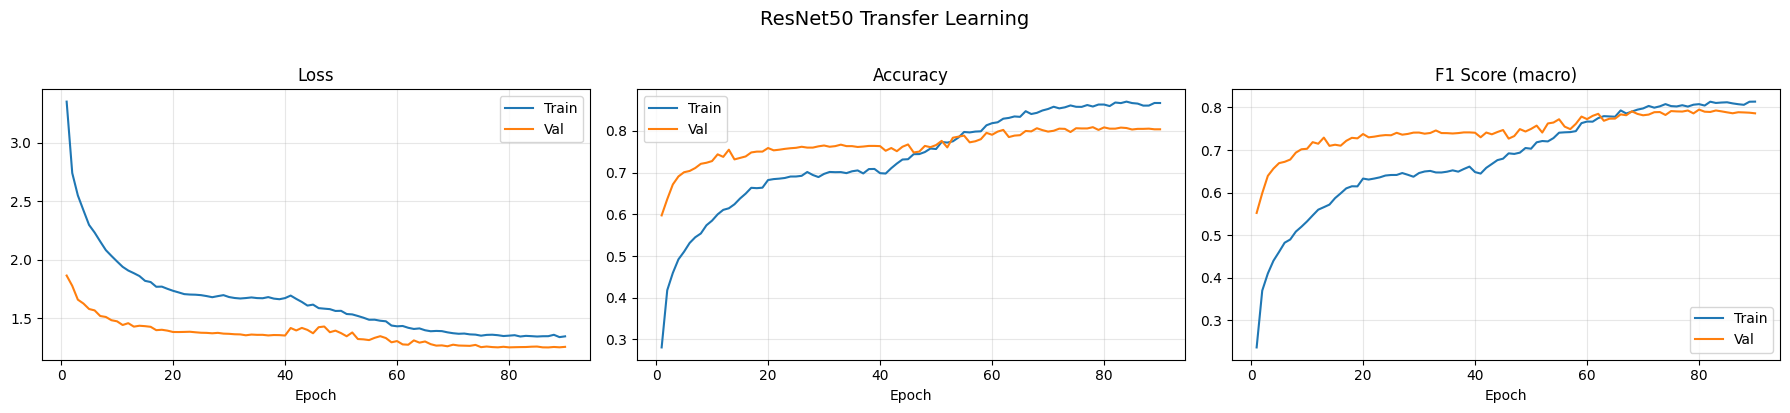

Best epoch (lowest val_loss): 87
  Val Loss: 1.2492
  Val Acc:  0.8051
  Val F1:   0.7889


In [9]:
plot_learning_curves([history_phase1, history_phase2], title="ResNet50 Transfer Learning")

### Test Evaluation


  ResNet50 Transfer Learning - Test Evaluation
  Test Loss:     1.2485
  Test Accuracy: 0.8067
  Test F1 Macro: 0.7918

Classification Report:
                       precision    recall  f1-score   support

       Albrecht_Durer       0.93      0.91      0.92        87
      Boris_Kustodiev       0.83      0.51      0.63        67
     Camille_Pissarro       0.68      0.72      0.70        93
        Childe_Hassam       0.74      0.69      0.71        58
         Claude_Monet       0.92      0.71      0.80       141
          Edgar_Degas       0.85      0.80      0.83        65
        Eugene_Boudin       0.90      0.88      0.89        59
         Gustave_Dore       0.82      0.99      0.90        80
           Ilya_Repin       0.59      0.67      0.63        58
      Ivan_Aivazovsky       0.79      0.93      0.86        61
        Ivan_Shishkin       0.78      0.76      0.77        55
  John_Singer_Sargent       0.85      0.81      0.83        83
         Marc_Chagall       0.97    

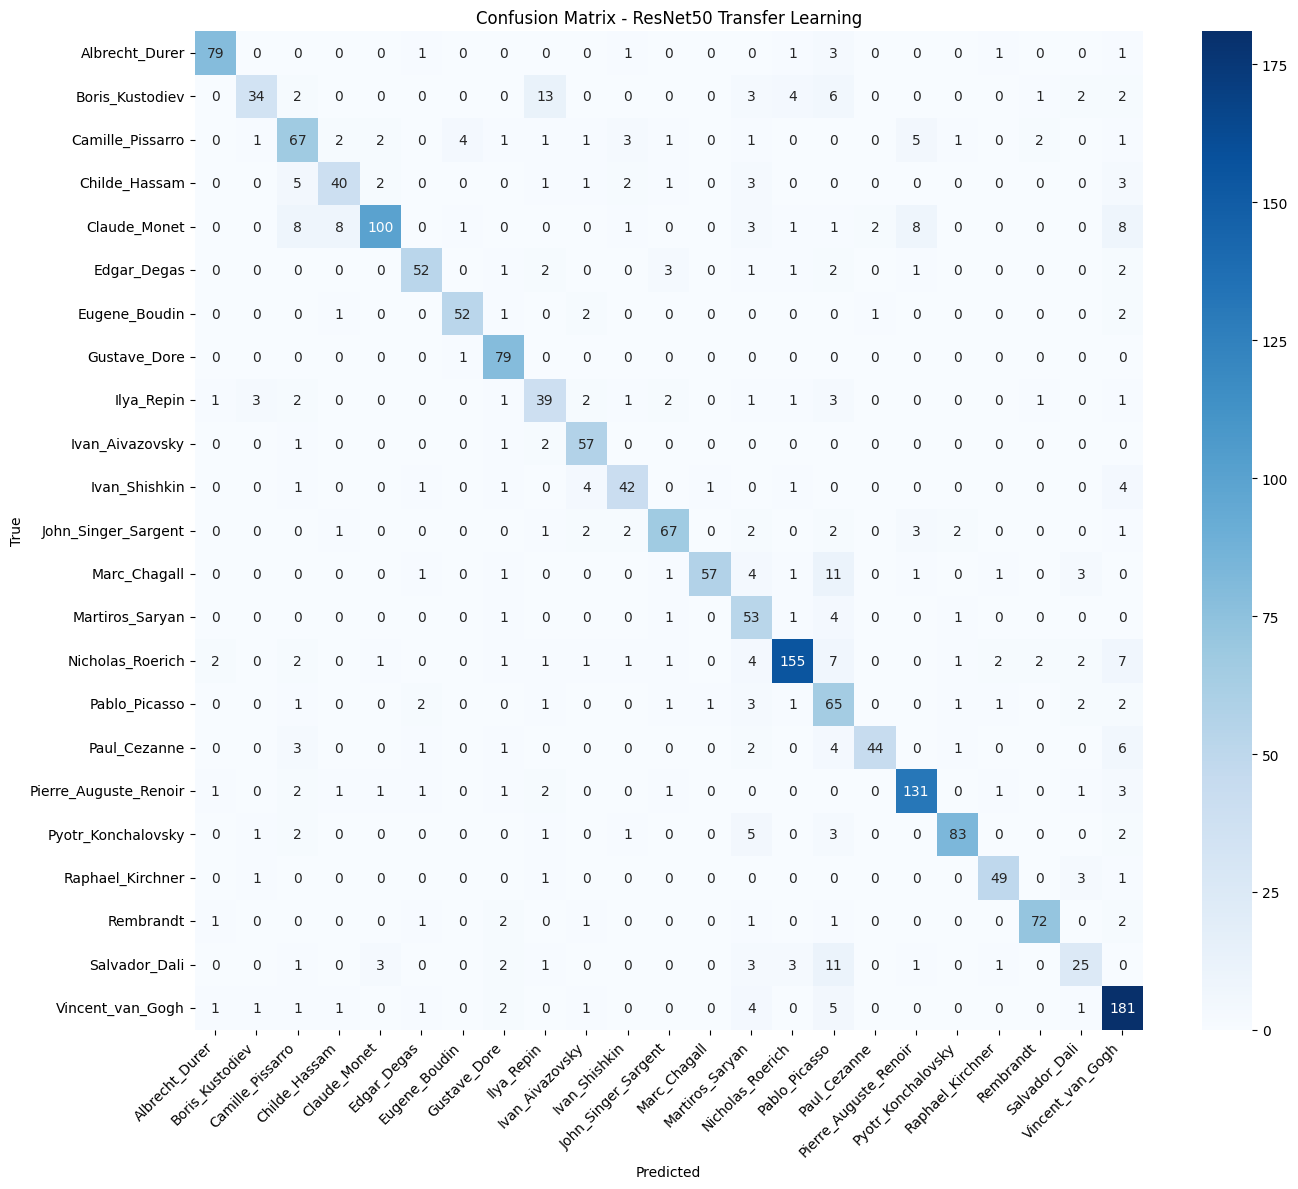

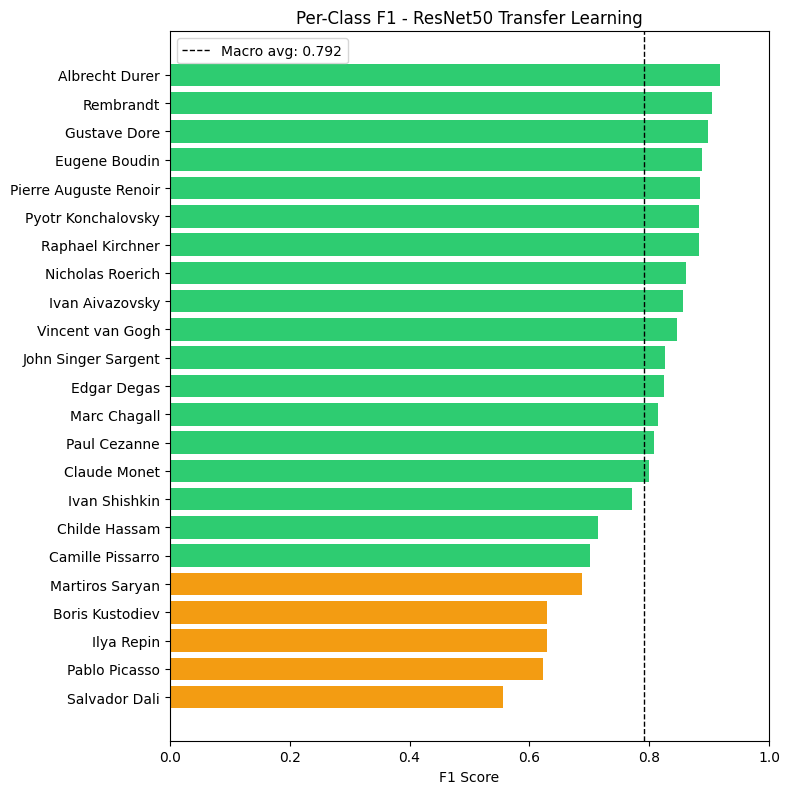

In [10]:
metrics_resnet = evaluate_model(model, test_ds, class_names, "ResNet50 Transfer Learning")

In [11]:
save_history([history_phase1, history_phase2], f"{CHECKPOINT_DIR}/resnet50_historyv3.json")

History saved to /content/drive/MyDrive/Deep-learning-project/models_results/resnet50/resnet50_historyv3.json


### Test Evaluation with TTA

Training was performed on Google Colab (NVIDIA T4 GPU) to leverage free GPU acceleration. However, Colab's free tier enforces a GPU usage limit of approximately 4–5 hours per session, which was fully consumed by the two-phase training procedure (frozen backbone + fine-tuning).

To avoid hitting the quota and losing access to the runtime, the final evaluation steps - loading the best checkpoint, running standard inference on the test set, and applying Test-Time Augmentation (TTA) - were executed **locally**. The best model was downloaded from Drive as a `.keras` file and reloaded with `keras.models.load_model()` for inference.

In [3]:
# Load the trained model
model = keras.models.load_model(
    "../models/resnet50/resnet50_v3_best.keras",
    compile=False
)

# Recompile (needed so model.evaluate() works inside evaluate_model and predict_tta)
model.compile(
    optimizer=keras.optimizers.AdamW(learning_rate=1e-5),
    loss=keras.losses.CategoricalCrossentropy(label_smoothing=0.1),
    metrics=["accuracy"],
)

In [11]:
IMG_SIZE = (256, 256)
BATCH_SIZE = 16

# All paths relative to notebooks/
train_dir = config['paths']['train_dir']
val_dir = config['paths']['val_dir']
test_dir = config['paths']['test_dir']

_, _, test_ds, class_names = load_datasets(
    train_dir, val_dir, test_dir,
    img_size=IMG_SIZE, batch_size=BATCH_SIZE,
)
test_ds = test_ds.prefetch(tf.data.AUTOTUNE)

Found 9282 files belonging to 23 classes.
Found 1980 files belonging to 23 classes.
Found 2012 files belonging to 23 classes.
Classes (23): ['Albrecht_Durer', 'Boris_Kustodiev', 'Camille_Pissarro', 'Childe_Hassam', 'Claude_Monet', 'Edgar_Degas', 'Eugene_Boudin', 'Gustave_Dore', 'Ilya_Repin', 'Ivan_Aivazovsky', 'Ivan_Shishkin', 'John_Singer_Sargent', 'Marc_Chagall', 'Martiros_Saryan', 'Nicholas_Roerich', 'Pablo_Picasso', 'Paul_Cezanne', 'Pierre_Auguste_Renoir', 'Pyotr_Konchalovsky', 'Raphael_Kirchner', 'Rembrandt', 'Salvador_Dali', 'Vincent_van_Gogh']



  ResNet50 - Test Evaluation
  Test Loss:     1.2485
  Test Accuracy: 0.8067
  Test F1 Macro: 0.7918

Classification Report:
                       precision    recall  f1-score   support

       Albrecht_Durer       0.93      0.91      0.92        87
      Boris_Kustodiev       0.83      0.51      0.63        67
     Camille_Pissarro       0.68      0.72      0.70        93
        Childe_Hassam       0.74      0.69      0.71        58
         Claude_Monet       0.92      0.71      0.80       141
          Edgar_Degas       0.85      0.80      0.83        65
        Eugene_Boudin       0.90      0.88      0.89        59
         Gustave_Dore       0.82      0.99      0.90        80
           Ilya_Repin       0.59      0.67      0.63        58
      Ivan_Aivazovsky       0.79      0.93      0.86        61
        Ivan_Shishkin       0.78      0.76      0.77        55
  John_Singer_Sargent       0.85      0.81      0.83        83
         Marc_Chagall       0.97      0.70      0.81  

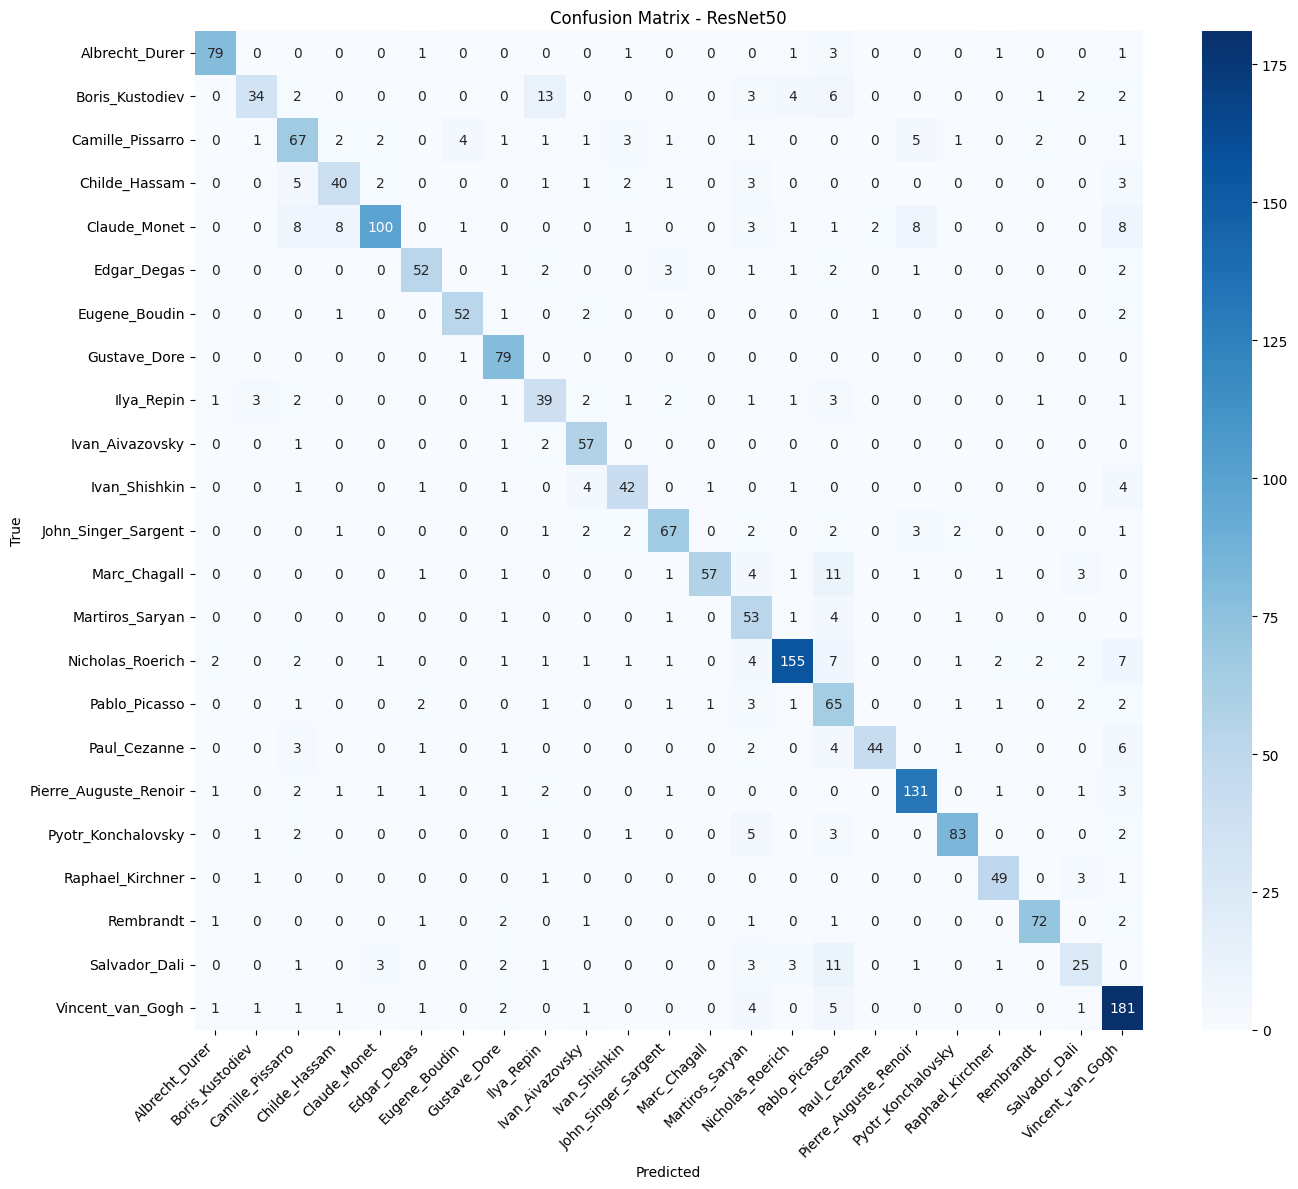

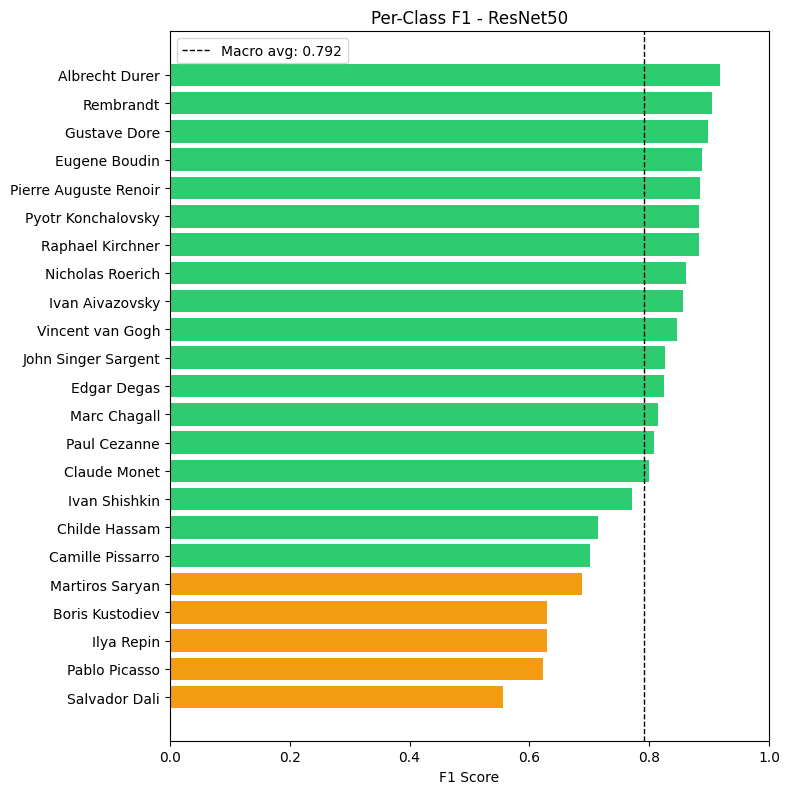

In [12]:
metrics_resnet = evaluate_model(model, test_ds, class_names, "ResNet50")

In [23]:
test_loss_tta, test_acc_tta, test_f1_tta, y_true_tta, y_pred_tta, probs_tta = predict_tta(
    model, test_ds, n_augmentations=7
)

TTA Results - Loss: 1.2485 | Accuracy: 0.8519 | F1: 0.8409



  ResNet50 + TTA - Test Evaluation
  Test Loss:     1.2485
  Test Accuracy: 0.8519
  Test F1 Macro: 0.8409

Classification Report:
                       precision    recall  f1-score   support

       Albrecht_Durer       0.95      0.95      0.95        87
      Boris_Kustodiev       0.84      0.63      0.72        67
     Camille_Pissarro       0.73      0.73      0.73        93
        Childe_Hassam       0.85      0.78      0.81        58
         Claude_Monet       0.86      0.83      0.84       141
          Edgar_Degas       0.79      0.85      0.81        65
        Eugene_Boudin       0.88      0.90      0.89        59
         Gustave_Dore       0.95      0.97      0.96        80
           Ilya_Repin       0.73      0.66      0.69        58
      Ivan_Aivazovsky       0.88      0.97      0.92        61
        Ivan_Shishkin       0.82      0.82      0.82        55
  John_Singer_Sargent       0.76      0.84      0.80        83
         Marc_Chagall       0.91      0.84      

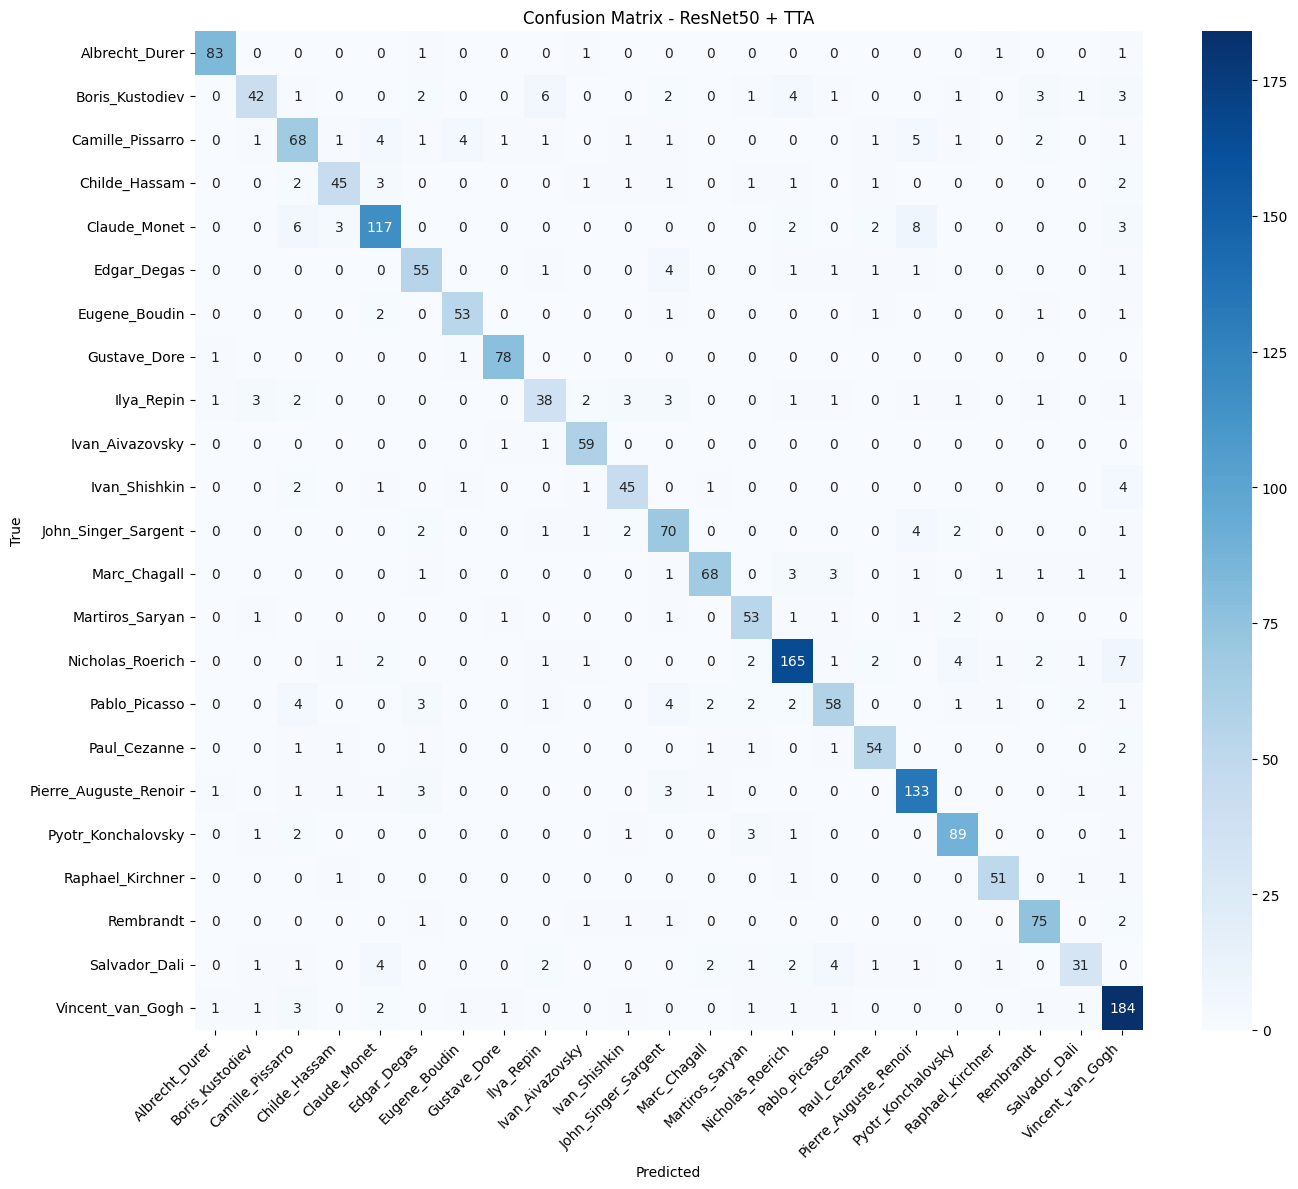

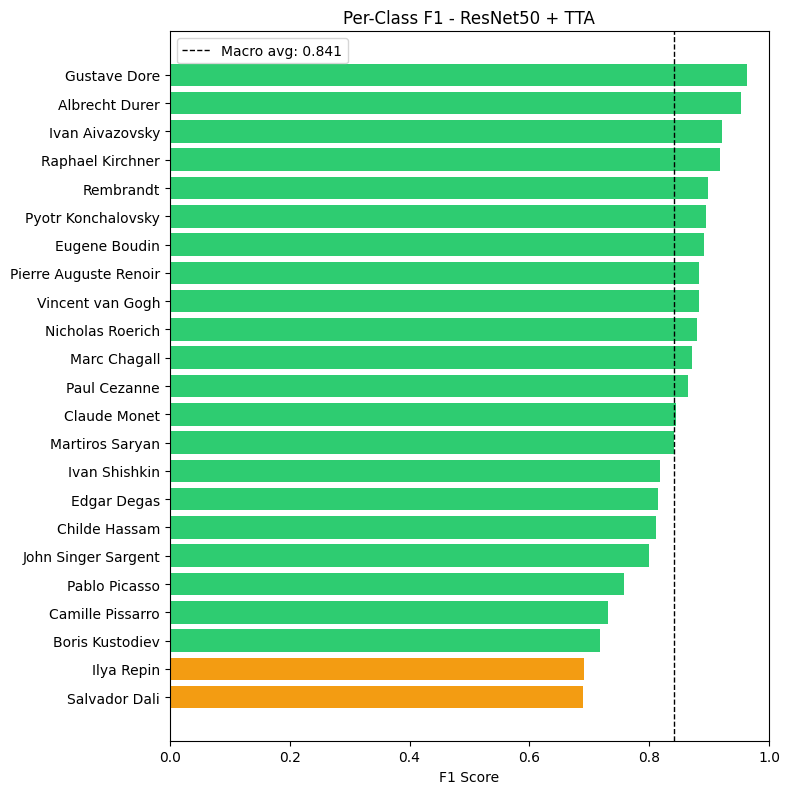

In [24]:
metrics_resnet_tta = evaluate_from_predictions(
    y_true_tta, y_pred_tta, probs_tta,
    class_names,
    model_name="ResNet50 + TTA",
    test_loss=test_loss_tta,
)